# 프로젝트: Transformer 구조를 GPT로 변경

## Quest 평가 기준

1. Transformer와 비교해 변경이 필요한 부분을 서술하였다.
- 제출 노트북 파일 첫부분에 텍스트 블럭으로 서술. 아키텍쳐 상 변경사항을 블럭단위로 서술
- 코드 블럭에 변경사항을 주석으로 표시

2. 모델의 입력 형태에 맞게 전처리를 수행하였다.
- Decoder 기반의 생성 모델임을 감안하여 챗봇 데이터를 변형
- pretrain을 위한 데이터셋과 학습만 고려

3. 모델의 입력 블럭을 GPT 논문에 기반하여 수정하였다.
- 모델의 input이 정상적으로 구성되었는지 확인
- 데이터에 위치 정보를 추가하는 과정을 구현

4. GPT 모델을 정상적으로 구성하였다.
- model.summary, model.fit 결과 캡쳐 첨부
- 노드의 transformer 코드를 수정하여 GPT1 모델을 구성

5. 입력에 따른 출력이 생성되었다.
- 출력 결과물의 수준에 상관없이 모델이 정상적으로 동작하는지 확인

---

## [평가 1] Transformer와 비교해 변경이 필요한 부분

코드 중 변경한 부분은 # [변경]으로 표기하였다.

### 1. 입력 구성

데이터셋은 질문-답변 형식이다. Transformer에서는 Encoder 입력으로 질문, Decoder 입력으로 답변을 넣어 두 개의 입력을 사용했다. 그러나 GPT는 Decoder 기반의 모델이므로 하나의 연속된 시퀀스로 합쳐야 한다.
```
입력 문장: Strat + Qeustion + Delim + Answer + Extract
```
fine-tuning은 수행하지 않으므로, Extract 토큰은 분류 헤드에 넣을 표현을 뽑는 원래 역할 대신 시퀀스 종료 토큰으로만 사용한다.

**(1) Delim 토큰 추가**

질문과 답변이 한 줄로 이어지면 모델이 어디까지가 질문인지 알 수 없기 때문에 Delim을 통해 경계를 표시한다. SentencePiece에 하나의 토큰(id=4)로 등록한다. 추론에서는 `Start + Question + Delim`까지를 프롬프트로 주고 그 뒤를 생성하게 한다.

**(2) MAX_LENGTH 22 -> 30**

시퀀스 길이가 `질문 + 답변 + 특수토큰 3개`로 늘어났으므로 MAX_LENGTH도 늘린다.

### 2. 임베딩 블럭

**(1) 학습 가능한 위치 임베딩**

Sin/Cos 함수 기반의 고정 인코딩 대신 학습 가능한 위치 임베딩을 사용한다. 위치별 벡터가 수식으로 고정되지 않고, 모델이 훈련되면서 데이터와 함께 최적화된다.

**(2) 초기화를 N(0, 0.02)로 통일**

임베딩의 초기 크기를 논문에 나와있는 초기화로 설정한다. 

**(3) 출력층 가중치 공유**

```
P(u) = softmax(h_n * W_e^T)
```

출력층이 입력 토큰 임베딩과 같은 가중치 행렬을 공유한다. 

### 3. Encoder 블럭 제거

GPT는 Decoder만 사용하므로 EncoderLayer와 Encoder 클래스를 삭제한다.

**함께 사라지는 것**
- 인코더 임베딩
- 인코더용 패딩 마스크: 마스크는 `create_look_ahead_mask()`만 남긴다
- Decoder의 Cross-Attetnion이 참조하던 enc_outputs를 제거한다.
- Encoder와 Decoder를 묶던 Transformer 래퍼


### 4. Decoder 블럭 -> GPT 블럭

**(1) Cross-Attention 제거**

Encoder를 삭제했으므로 인코더와 디코더를 연결하는 레이어는 필요하지 않다. Cross-Attention과 그에 딸린 LayerNorm, Dropout을 삭제해 Masked Self-Attention과 Feed-Forward 두 개의 레이어만 남긴다.

**(2) 활성화 함수 ReLU -> GeLU**

논문에서 GeLU를 사용한다. 

**(3) DecoderLayer -> GPTBlock**

Encoder는 없이 Masked Self-Attention과 FFN으로만 이루어진 동일한 블럭을 num_layers만큼 쌓는 구조이므로 GPTBlock으로 이름을 수정하였다. 


### 5. 학습

**(1) 시퀀스 전체를 한 칸 밀어 input과 target을 만든다**

Transformer는 답변 시퀀스만 한 칸 밀어 디코더 입력과 정답을 만들었다.
```
dec_input = a_tokens[:-1]
target = a_tokens[1:]
```
GPT는 시퀀스가 하나이므로 결합한 시퀀스를 한 칸 밀어서 잘라 입력과 정답을 만든다.
```
input = seq[:-1]
target = seq[1:]
```
모든 위치에서 바로 다음 토큰이 정답이 된다. 학습의 목적이 다음 토큰을 에측하는 것이므로 입력과 출력을 나누지 않는다. 이에 따라 질문도 예측 문제에 추가된다. 

**(2) 패딩 길이를 MAX_LENGTH + 1로 맞춘다**

Transformer는 MAX_LENGTH까지 패딩한 뒤 잘랐으므로 디코더 입력이 MAX_LENGTH - 1이었지만, GPT는 MAX_LENGTH + 1까지 패딩한다. 한 칸 밀어 자르면 길이가 하나 줄어들기 때문에 MAX_LENGTH + 1에서 잘라야 input과 target이 max_length가 되어 위치 임베딩 크기와 동일해진다.

**코드 변경**

- Dataset: 답변만 담던 dec_input/target -> 결합 시퀀스의 input_ids/target
- Dataset 반환값: 3-tuple -> 2-tuple
- forward: model(enc_input, dec_input) -> model(x)
- train_step / evaluate: 배치 언패킹 3개 -> 2개

### 6. 추론

**(1) 두 개의 입력을 프롬프트 하나로 합친다**

GPT는 입력이 하나이므로 Start + Question + Delim 까지를 프롬프트로 만들고, 생성한 토큰을 여기에 이어붙여 model(generated) 하나만 호출한다. 모델은 Delim 다음에 답변의 첫 토큰이 온다는 것을 학습한 생태이므로 추론의 입력 형식이 학습과 달라지면 모델이 겪어본 적 없는 입력이 되어 생성이 안된다. 

**(2) 프롬프트 구간은 제외하고 반환한다**

ransformer의 dec_input은 답변만 담고 있어 전체를 그대로 디코딩하면 되었다. GPT의 시퀀스에는 프롬프트로 넣은 질문이 들어 있으므로, 프롬프트 길이 이후의 토큰만 잘라 반환한다.
```
answer_ids = generated.squeeze(0).tolisk()[len(prompt):]
```

**코드 변경**

- 함수명: decoder_inference -> generate
- 호출: model(enc_input, dec_input) -> model(generated)
- sentence_generation: 반환된 답변 토큰만 디코딩 (기존의 GetPieceSize 필터 제거)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import sentencepiece as spm

import math
import os
import re
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Step 1. 데이터 수집하기
---
한국어 챗봇 데이터는 송영숙님이 공개한 챗봇 데이터를 사용합니다.

이 데이터는 아래의 링크에서 다운로드할 수 있습니다.

- [songys/Chatbot_data](https://github.com/songys/Chatbot_data/blob/master/ChatbotData.csv)

In [2]:
data = pd.read_csv('data/ChatbotData.csv')
print(data.sample(10))

                       Q                         A  label
2222             비정규직 차별      차별이 가장 안 좋은 건데 슬프네요.      0
2794                 심술나               좋은 생각만 하세요.      0
8452   한번쯤 진하게 아픈것도 괜찬아.                   긍정적이네요.      1
3565            웃으면 안되는데                 웃으면 복이와요.      0
6608              사랑한다는것               헤아릴 수 없는 것.      1
1045              뇌용량 초과           눈을 감고 명상을 해보세요.      0
3383      오후되면 얼굴에 개기름 껴                 세수하고 오세요.      0
228         공부방법이 잘못된걸까?  나한테 맞는 공부 방법 찾는 게 시급하네요.      0
240          공연 보러 가고 싶어              친구와 같이 가보세요.      0
10721      연애 잘하는 사람 부러워                 잘할 수 있어요.      2


In [3]:
print('data 총 개수: ', len(data))
print(data.isnull().sum())   # 결측치 확인

data 총 개수:  11823
Q        0
A        0
label    0
dtype: int64


In [4]:
# 질문(Q)과 답변(A)을 각각의 리스트로 분리
questions = data['Q'].tolist()
answers = data['A'].tolist()

print('questions 개수: ', len(questions))
print('answers 개수: ', len(answers))
print('questions[:3]: ', questions[:3])
print('answers[:3]: ', answers[:3])

questions 개수:  11823
answers 개수:  11823
questions[:3]:  ['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다']
answers[:3]:  ['하루가 또 가네요.', '위로해 드립니다.', '여행은 언제나 좋죠.']


## Step 2. 데이터 전처리하기
---

In [5]:
# 전처리 함수
def preprocess_sentence(sentence):
    # 입력받은 sentence를 소문자로 변경하고 양쪽 공백을 제거
    sentence = sentence.lower().strip()

    # 단어와 구두점(punctuation) 사이의 거리를 만듭니다.
    # student와 온점 사이에 거리를 만듭니다.
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

    # (가-힣, ㄱ-ㅎ, ㅏ-ㅣ, a-z, A-Z, 0-9, ".", "?", "!", ",")를 제외한 모든 문자를 공백인 ' '로 대체합니다.
    sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9?.!,]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence)   # 연속 공백 정리
    sentence = sentence.strip()
    return sentence

"ㅋㅋ", "ㅠㅠ" 등을 감정 신호로 보아 남겨두기로 결정

In [6]:
sample_sentence = questions[0]

preprocessed_sentence = preprocess_sentence(sample_sentence)
print(preprocessed_sentence)

12시 땡 !


In [7]:
# 전처리 적용 후 (질문, 답변) 병렬 데이터를 만듦
pairs = []
for q, a in zip(questions, answers):
    q = preprocess_sentence(q)
    a = preprocess_sentence(a)

    # 빈 문장이 된 쌍은 제외
    if len(q) == 0 or len(a) == 0:
        continue

    pairs.append((q, a))

print('전처리 후 쌍 개수: ', len(pairs), f'({len(questions) - len(pairs)}개 제외)')

# 질문과 답변이 모두 같은 완전 중복 쌍 제거
seen = set()
unique_pairs = []
for pair in pairs:
    if pair in seen:
        continue
    seen.add(pair)
    unique_pairs.append(pair)

print('중복 제거 후 쌍 개수: ', len(unique_pairs), f'(중복 {len(pairs) - len(unique_pairs)}개 제거)')
pairs = unique_pairs

# 만들어진 병렬 데이터 확인
for q, a in pairs[:5]:
    print('Q: ', q)
    print('A: ', a)
    print()

전처리 후 쌍 개수:  11823 (0개 제외)
중복 제거 후 쌍 개수:  11749 (중복 74개 제거)
Q:  12시 땡 !
A:  하루가 또 가네요 .

Q:  1지망 학교 떨어졌어
A:  위로해 드립니다 .

Q:  3박4일 놀러가고 싶다
A:  여행은 언제나 좋죠 .

Q:  3박4일 정도 놀러가고 싶다
A:  여행은 언제나 좋죠 .

Q:  ppl 심하네
A:  눈살이 찌푸려지죠 .



## Step 3. SentencePiece 사용하기
---

In [9]:
sents = [s for pair in pairs for s in pair]

# pairs를 txt 파일로 저장
corpus_file = "clean_corpus_ko.txt"
with open(corpus_file, 'w', encoding='utf-8') as f:
    for q, a in pairs:
        f.write(q + "\n")
        f.write(a + "\n")

In [21]:
spm.SentencePieceTrainer.Train(
    input=corpus_file,
    model_prefix="spm_ko",
    vocab_size=4000,
    character_coverage=0.9995,   # 한국어 권장
    model_type="bpe",
    max_sentence_length=999999,
    bos_id=1,  # <s> (Beginning of Sentence) 설정
    eos_id=2,  # </s> (End of Sentence) 설정
    pad_id=0,  # Padding ID 설정
    unk_id=3,  # Unknown Token ID 설정
    user_defined_symbols=['<delim>'] # [변경] Delim 토큰 추가
)

True

In [65]:
sp = spm.SentencePieceProcessor()
sp.Load("spm_ko.model")

print('vocab size:', sp.get_piece_size())   # vocab 크기
print('delim ID: ', sp.piece_to_id('<delim>'))   # [변경] delim ID 확인
all_ids = [i for s in sents for i in sp.encode(s)]   # UNK 비율
print('UNK 비율: {:.4f}%'.format(
    sum(1 for i in all_ids if i == sp.unk_id()) / len(all_ids) * 100))

print('문장당 평균 토큰 수: {:.2f}'.format(len(all_ids) / len(sents)))

# 예제 확인
sentence = "3박4일 놀러가고 싶다"

sentence = preprocess_sentence(sentence)
print("전처리 후의 문장:", sentence)

# 1) 토크나이징 (subword 단위로 분할)
tokens = sp.encode(sentence, out_type=str)
print("Tokenized:", tokens)

# 2) 인코딩 (서브워드를 정수 ID로 변환)
encoded = sp.encode(sentence, out_type=int)
print("Encoded:", encoded)

# 3) 디코딩 (정수 ID → 원본 문장 복원)
decoded = sp.decode(encoded)
print("Decoded:", decoded)

vocab size: 4000
delim ID:  4
UNK 비율: 0.1157%
문장당 평균 토큰 수: 6.51
전처리 후의 문장: 3박4일 놀러가고 싶다
Tokenized: ['▁3', '박', '4', '일', '▁놀러', '가고', '▁싶다']
Encoded: [480, 3437, 3405, 2979, 1117, 970, 203]
Decoded: 3박4일 놀러가고 싶다


In [23]:
from collections import Counter

cnt = Counter(all_ids)
size = sp.get_piece_size()
print('실제 등장한 조각: {} / {} ({:.1f}%)'.format(len(cnt), size, len(cnt) / size * 100))
print('5회 미만 등장: {} ({:.1f}%)'.format(
    sum(1 for v in cnt.values() if v < 5),
    sum(1 for v in cnt.values() if v < 5) / size * 100))

실제 등장한 조각: 3886 / 4000 (97.2%)
5회 미만 등장: 373 (9.3%)


### MAX_LEN 설정

결합 시퀀스의 최소 길이   : 5
결합 시퀀스의 최대 길이   : 46
결합 시퀀스의 평균 길이   : 16.02
결합 시퀀스의 90 분위 길이 : 22
결합 시퀀스의 95 분위 길이 : 24
결합 시퀀스의 99 분위 길이 : 29


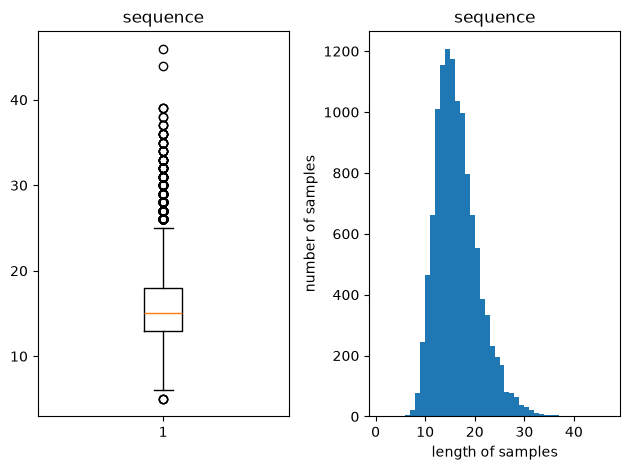

In [24]:
# 토큰 길이 분포 출력
import matplotlib.pyplot as plt

# [변경] GPT는 둘을 하나의 시퀀스로 합치므로 결합 길이 분포만 확인한다.
#            +3 = Start(<s>) + Delim(<delim>) + Extract(</s>)
q_tokens = [len(sp.encode(q)) for q, a in pairs]
a_tokens = [len(sp.encode(a)) for q, a in pairs]

NUM_SPECIAL = 3
seq_tokens = [qt + at + NUM_SPECIAL for qt, at in zip(q_tokens, a_tokens)]

print('결합 시퀀스의 최소 길이   : {}'.format(np.min(seq_tokens)))
print('결합 시퀀스의 최대 길이   : {}'.format(np.max(seq_tokens)))
print('결합 시퀀스의 평균 길이   : {:.2f}'.format(np.mean(seq_tokens)))
print('결합 시퀀스의 90 분위 길이 : {:.0f}'.format(np.percentile(seq_tokens, 90)))
print('결합 시퀀스의 95 분위 길이 : {:.0f}'.format(np.percentile(seq_tokens, 95)))
print('결합 시퀀스의 99 분위 길이 : {:.0f}'.format(np.percentile(seq_tokens, 99)))

plt.subplot(1, 2, 1)
plt.boxplot(seq_tokens)
plt.title('sequence')

plt.subplot(1, 2, 2)
plt.hist(seq_tokens, bins=range(1, np.max(seq_tokens) + 2))
plt.title('sequence')
plt.xlabel('length of samples')
plt.ylabel('number of samples')

plt.tight_layout()
plt.show()

In [27]:
def below_threshold_len(max_length, seq_tokens):
    """MAX_LENGTH 안에 들어오는 시퀀스의 비율 출력

    [변경] GPT는 둘을 하나로 합치므로 결합 길이(seq_tokens) 하나로 판정
    """
    cnt = sum(1 for st in seq_tokens if st <= max_length)
    print('MAX_LENGTH=%s 이하인 쌍의 비율: %.4f  (유지 %s / %s, 손실 %s쌍)'
          % (max_length, cnt / len(seq_tokens), cnt, len(seq_tokens), len(seq_tokens) - cnt))

In [28]:
max_len = 30
below_threshold_len(max_len, seq_tokens)

MAX_LENGTH=30 이하인 쌍의 비율: 0.9944  (유지 11683 / 11749, 손실 66쌍)


### Dataset 구축하기

In [64]:
class KoreanDataset(Dataset):
    """[변경] GPT는 Decoder 기반 언어 모델이므로 하나의 시퀀스로 합치고,
       그 시퀀스를 한 칸씩 밀어 input/target을 구성한다.

           full   : <s> Question <delim> Answer </s> <pad> <pad> ...
           input  : full[:-1]
           target : full[1:]
    """

    def __init__(self, pairs, sp, max_length):
        super().__init__()
        self.sp = sp
        self.max_length = max_length
        self.data = []

        # [변경] Start / Delim / Extract를 SentencePiece 토큰에 대응
        bos_id = sp.bos_id()                   # Start
        eos_id = sp.eos_id()                   # Extract
        pad_id = sp.pad_id()
        delim_id = sp.piece_to_id('<delim>')   # Delim
        
        for q_text, a_text in pairs:
            # 1) 토크나이즈
            q_ids = sp.EncodeAsIds(q_text)
            a_ids = sp.EncodeAsIds(a_text)

            # 2) [변경] 하나의 시퀀스로 결합: Start + Question + Delim + Answer + Extract
            seq = [bos_id] + q_ids + [delim_id] + a_ids + [eos_id]

            # 3) 길이 제한
            if len(seq) > max_length:
                continue

            # 4) [변경] max_length + 1까지 패딩
            seq = seq + [pad_id] * (max_length + 1 - len(seq))

            # 5) [변경] 시퀀스를 한 칸씩 밀어 input / target 생성
            self.data.append({
                "input_ids": seq[:-1],
                "target": seq[1:],
            })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        # [변경] enc_input이 사라져 반환값이 3-tuple에서 2-tuple로  바뀜
        input_ids = torch.tensor(sample["input_ids"], dtype=torch.long)
        target = torch.tensor(sample["target"], dtype=torch.long)
        return input_ids, target

In [34]:
# [변경] MAX_LENGTH을 30으로 설정
MAX_LENGTH = 30

dataset = KoreanDataset(pairs, sp, max_length=MAX_LENGTH)
print('학습 시퀀스: {} / {} (길이 초과 {}개 제외)'.format(
    len(dataset), len(pairs), len(pairs) - len(dataset)))

학습 시퀀스: 11683 / 11749 (길이 초과 66개 제외)


In [35]:
# [변경] 모델 input이 정상적으로 구성되었는지 확인
input_ids, target = dataset[0]

print('input  shape:', tuple(input_ids.shape), '/ target shape:', tuple(target.shape))
print()
print('input  ids :', input_ids.tolist())
print('target ids :', target.tolist())
print()

# 특수 토큰 위치 확인 (Start / Delim / Extract)
print('토큰 단위 복원:', [sp.id_to_piece(i) for i in input_ids.tolist()])
print()
print('복원한 문장 :', sp.decode([i for i in input_ids.tolist() if i != sp.pad_id()]))

input  shape: (30,) / target shape: (30,)

input  ids : [1, 344, 3258, 2971, 2929, 3682, 113, 4, 381, 2937, 214, 29, 34, 5, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
target ids : [344, 3258, 2971, 2929, 3682, 113, 4, 381, 2937, 214, 29, 34, 5, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

토큰 단위 복원: ['<s>', '▁1', '2', '시', '▁', '땡', '▁!', '<delim>', '▁하루', '가', '▁또', '▁가', '네요', '▁.', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']

복원한 문장 : 12시 땡 !<delim> 하루가 또 가네요 .


## Step 4. 모델 구성하기
---

### DataLoader 구성하기

In [36]:
from torch.utils.data import random_split

# Early Stopping 판단을 위해 학습/검증 데이터로 분할
VAL_RATIO = 0.1   # 훈련 90% | 검증 10%
BATCH_SIZE = 32

val_size = int(len(dataset) * VAL_RATIO)
train_size = len(dataset) - val_size

# 재현성을 위해 seed 고정
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=generator)
print('train: {} / validation: {}'.format(len(train_dataset), len(val_dataset)))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
print('steps per epoch:', len(train_loader))

# [변경] enc_input이 사라져 배치가 (input_ids, target)로 바뀜
for input_ids, target in train_loader:
    print(input_ids.size())
    print(target.size())
    break

train: 10515 / validation: 1168
steps per epoch: 329
torch.Size([32, 30])
torch.Size([32, 30])


### 모델

#### Positional Embedding: 학습 가능한 위치 정보

In [37]:
class PositionalEmbedding(nn.Module):
    """[변경] sin/cos 고정 인코딩 -> 학습 가능한 위치 임베딩"""

    def __init__(self, position, d_model):
        super(PositionalEmbedding, self).__init__()
        self.d_model = d_model     # 임베딩 벡터의 차원
        self.position = position   # 위치 임베딩 테이블 크기

        # [변경] 학습되는 nn.Embedding. 초기화는 GPT._init_weights 가 N(0, 0.02)로 처리.
        self.pos_embedding = nn.Embedding(position, d_model)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        seq_len = x.size(1)

        # [변경] 0 ~ seq_len-1 의 위치 인덱스를 만들어 테이블에서 조회
        positions = torch.arange(seq_len, device=x.device)     # (seq_len,)
        pos_emb = self.pos_embedding(positions).unsqueeze(0)   # (1, seq_len, d_model)

        return x + pos_emb   # 배치 방향으로 브로드캐스트

#### Scaled Dot-Product Attention: 스케일링한 어텐션

In [38]:
def scaled_dot_product_attention(query, key, value, mask=None):

    # 1) Q와 K의 내적을 통해 score(유사도) 계산
    # key.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # 2) depth에 따라 정규화
    depth = key.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 3) 마스크가 주어졌다면 -1e9(아주 작은 값)를 더해 소프트맥스에서 제외시키도록 함
    if mask is not None:
        # 텐서플로우: logits += (mask * -1e9)
        # 파이토치 동일 적용
        logits = logits + (mask * -1e9)

    # 4) 소프트맥스 계산해 attention weights 생성
    attention_weights = F.softmax(logits, dim=-1)

    # 5) attention weights와 value의 내적
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

#### Multi-Head Attention: 병렬 연산 어텐션

In [39]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        # matmul이 뒤쪽 2개 축만 보기 때문에 seq_len, depth가 뒤에 오도록 변경해야 함
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        # 반환값: (batch_size, 1, seq_len, seq_len), 두 번째 반환값: 어텐션 가중치
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output


#### Multi-Head Attention shape 흐름

d_model=256, num_heads=8, depth=32, batch=32, seq_len=30

| 단계 | shape |
|---|---|
| 입력 query/key/value | (32, 30, 256) |
| Linear 통과 후 | (32, 30, 256) |
| view (헤드 분할) | (32, 30, 8, 32) |
| permute | (32, 8, 30, 32) |
| 어텐션 스코어 (내부) | (32, 8, 30, 30) |
| 어텐션 출력 | (32, 8, 30, 32) |
| permute 복원 | (32, 30, 8, 32) |
| view (concat) | (32, 30, 256) |
| out_dense | (32, 30, 256) |

#### Mask
- Padding Mask: pad 처리된 위치를 가림
- Look ahead Mask: 미래 정보 차단
- [변경] Transformer는 인코더 패딩 / 디코더 look-ahead / 인코더-디코더 패딩 3종을 사용했다.
  GPT는 시퀀스가 하나뿐이므로 둘을 결합한 `create_look_ahead_mask` 하나만 사용한다.

In [40]:
def create_padding_mask(x):
    # x == 0 위치를 찾아 float형 1로 변환
    mask = (x == 0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask

In [67]:
def create_look_ahead_mask(x):
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 하삼각 행렬(tril) 생성 후 1에서 빼서
    # 상삼각이 1, 하삼각(자기 자신 포함)이 0이 되도록 설정
    # => 미래 토큰(자신 인덱스보다 큰 위치) 마스킹
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 생성 (shape: (batch_size, 1, 1, seq_len))
    padding_mask = create_padding_mask(x)

    # look_ahead_mask: (seq_len, seq_len) -> (1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(0)
    # -> (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead 마스크와 패딩 마스크를 합성 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 브로드캐스팅으로 (batch_size, 1, seq_len, seq_len)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

#### GPT Block

In [42]:
class GPTBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(GPTBlock, self).__init__()   # [변경] DecoderLayer -> GPTBlock

        # 첫 번째 서브 레이어 (Masked Self-Attention)
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # [변경] 인코더-디코더 어텐션(encdec_mha) 제거 -> 서브 레이어 3개에서 2개로

        # 두 번째 서브 레이어 (피드포워드 네트워크)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Dense(units=ff_dim)
            nn.GELU(),                   # [변경] ReLU -> GELU
            nn.Linear(ff_dim, d_model)   # Dense(units=d_model)
        )
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        # 드롭아웃
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, look_ahead_mask=None):
        # 1) Masked Self-Attention
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # 잔차 연결 + LayerNorm (post-LN 유지)

        # 2) 피드포워드 (Dense -> GELU -> Dense)
        ffn_out = self.ffn(out1)
        ffn_out = self.dropout2(ffn_out)
        out2 = self.norm2(out1 + ffn_out)     # 잔차 연결 + LayerNorm

        return out2

#### GPT

In [68]:
class GPT(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,      # GPT Block 층 수
                 units,           # feed-forward 네트워크의 중간 차원(ff_dim)
                 d_model,         # 임베딩 및 내부 표현 차원
                 num_heads,       # 멀티헤드 어텐션의 헤드 수
                 max_length,      # 위치 임베딩 테이블 크기
                 dropout=0.1):
        super(GPT, self).__init__()
        self.d_model = d_model

        # [변경] Encoder / Decoder 가 각자 갖고 있던 임베딩이 하나로 통합
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = PositionalEmbedding(position=max_length, d_model=d_model)
        self.dropout = nn.Dropout(dropout)

        # [변경] Decoder 클래스를 없애고 블럭 스택을 GPT 안에 넣음
        self.blocks = nn.ModuleList([
            GPTBlock(d_model, num_heads, units, dropout)
            for _ in range(num_layers)
        ])

        # 최종 출력층: (d_model) -> (vocab_size)
        self.final_linear = nn.Linear(d_model, vocab_size, bias=False)

        # [변경] 가중치 초기화를 N(0, 0.02)로 통일
        self.apply(self._init_weights)

        # [변경] 출력층과 토큰 임베딩의 가중치 공유 (W_e^T)
        self.final_linear.weight = self.embedding.weight

    # [변경] 가중치 초기화
    @staticmethod
    def _init_weights(module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.LayerNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)

    def forward(self, x):
        # x: (batch_size, seq_len)

        # 1) look-ahead + 패딩 결합 마스크
        # [변경] 인코더 패딩 마스크와 인코더-디코더 패딩 마스크가 사라지고 하나만 남음
        look_ahead_mask = create_look_ahead_mask(x)

        # 2) [변경] 토큰 임베딩 + 위치 임베딩
        out = self.embedding(x)              # (batch_size, seq_len, d_model)
        out = self.pos_embedding(out)
        out = self.dropout(out)

        # 3) GPT Block
        for block in self.blocks:
            out = block(out, look_ahead_mask)   # (batch_size, seq_len, d_model)

        # 4) 최종 Dense (vocab_size)
        logits = self.final_linear(out)         # (batch_size, seq_len, vocab_size)
        return logits

In [69]:
# 하이퍼파라미터 설정
NUM_LAYERS = 2                    # GPT Block 층 수
D_MODEL = 256                     # 임베딩 및 내부 표현 차원
NUM_HEADS = 8                     # 멀티헤드 어텐션에서의 헤드 수
UNITS = 512                       # 피드포워드 신경망의 은닉 차원
DROPOUT = 0.3
VOCAB_SIZE = sp.get_piece_size()  # 단어 집합 크기 (토크나이저와 항상 일치)

print('VOCAB_SIZE:', VOCAB_SIZE)
print('MAX_LENGTH:', MAX_LENGTH)

# 모델 생성
model = GPT(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    max_length=MAX_LENGTH,
    dropout=DROPOUT
)

print('총 파라미터: {:,} (가중치 공유 반영)'.format(sum(p.numel() for p in model.parameters())))

# 모델 구조 확인
from torchinfo import summary

summary(
    model,
    input_data=torch.zeros(BATCH_SIZE, MAX_LENGTH, dtype=torch.long),
    col_names=("input_size", "output_size", "num_params"),
    depth=4,
)

VOCAB_SIZE: 4000
MAX_LENGTH: 30
총 파라미터: 2,085,888 (가중치 공유 반영)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
GPT                                      [32, 30]                  [32, 30, 4000]            --
├─Embedding: 1-1                         [32, 30]                  [32, 30, 256]             1,024,000
├─PositionalEmbedding: 1-2               [32, 30, 256]             [32, 30, 256]             --
│    └─Embedding: 2-1                    [30]                      [30, 256]                 7,680
├─Dropout: 1-3                           [32, 30, 256]             [32, 30, 256]             --
├─ModuleList: 1-4                        --                        --                        --
│    └─GPTBlock: 2-2                     [32, 30, 256]             [32, 30, 256]             --
│    │    └─MultiHeadAttention: 3-1      [32, 30, 256]             [32, 30, 256]             --
│    │    │    └─Linear: 4-1             [32, 30, 256]             [32, 30, 256]             65,792
│    │    │    └─Line

### Learning Rate 설정

In [70]:
def get_lr_lambda(warmup_steps, total_steps):
    """[변경] Noam 스케줄 -> 선형 warmup + cosine annealing 

    GPT는 최대 학습률을 2.5e-4로 직접 지정하고, 2000 step 동안 선형으로 올린 뒤 코사인 곡선을 따라 0까지 감소시킨다.
    """
    def lr_lambda(step):
        step = step + 1   # step은 0부터 시작하므로 +1로 보정

        # 1) warmup 구간: 0 -> 1 선형 증가
        if step <= warmup_steps:
            return step / warmup_steps

        # 2) annealing 구간: 1 -> 0 코사인 감소
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        progress = min(progress, 1.0)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    return lr_lambda

steps/epoch: 329 / 총 학습 스텝: 32900
warmup 종료 시점: 6.1 epoch


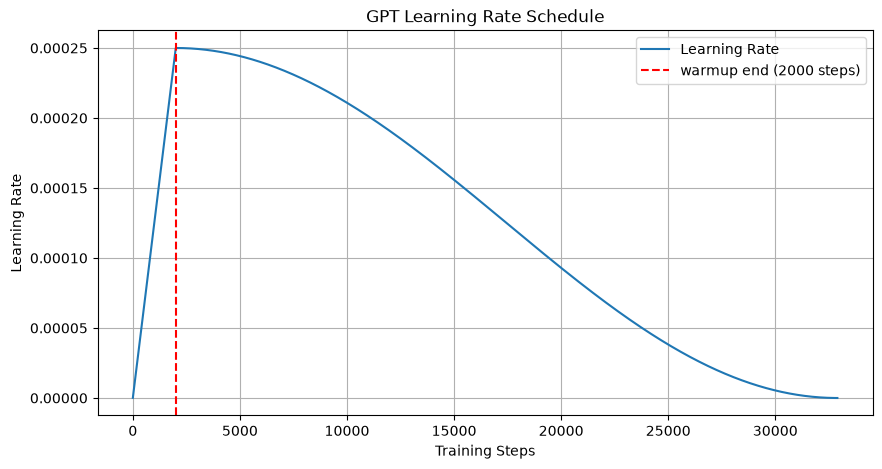

In [71]:
# 학습 설정
MAX_LR = 2.5e-4       # [변경] 논문의 최대 학습률
warmup_steps = 2000   # [변경] 논문의 warmup step
NUM_EPOCHS = 100      # Early Stopping이 있으므로 넉넉히 설정
PATIENCE = 10         # val_acc 기준

steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * NUM_EPOCHS
print('steps/epoch: {} / 총 학습 스텝: {}'.format(steps_per_epoch, total_steps))
print('warmup 종료 시점: {:.1f} epoch'.format(warmup_steps / steps_per_epoch))

# 학습률 스케줄 시각화
steps = np.arange(total_steps)
lr_lambda = get_lr_lambda(warmup_steps, total_steps)
learning_rates = [MAX_LR * lr_lambda(step) for step in steps]

plt.figure(figsize=(10, 5))
plt.plot(steps, learning_rates, label="Learning Rate")
plt.axvline(warmup_steps, color='r', linestyle='--',
            label="warmup end ({} steps)".format(warmup_steps))
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.title("GPT Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()

### Optimizer & Scheduler & Loss Function

In [72]:
# Optimizer 정의
# [변경] L2 regularization w=0.01 적용
optimizer = optim.AdamW(model.parameters(), lr=MAX_LR, betas=(0.9, 0.98), eps=1e-9, weight_decay=0.01)

# Scheduler 정의
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(warmup_steps, total_steps))

# Loss Function - label smoothing 적용
LABEL_SMOOTHING = 0.1
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id(), label_smoothing=LABEL_SMOOTHING)

def accuracy_function(y_pred, y_true, pad_id=0):
    """
    y_pred: (batch_size, seq_len, vocab_size)
    y_true: (batch_size, seq_len)
    """
    preds = y_pred.argmax(dim=-1)  # (batch_size, seq_len)
    mask = (y_true != pad_id)      # 정답이 패딩이 아닌 위치만 True
    correct = (preds == y_true) & mask   # 맞혔고, 채점 대상(mask)인 위치만 True
    acc = correct.float().sum() / mask.float().sum()
    return acc

In [73]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)
device

device(type='cuda')

### 훈련하기

In [74]:
def train_step(model, batch, optimizer, loss_function, device):
    model.train()
    # [변경] enc_input이 사라져 배치가 (input_ids, target)로 바뀜
    input_ids, target = [x.to(device) for x in batch]

    optimizer.zero_grad()

    # [변경] model(enc_input, dec_input) -> model(input_ids)
    logits = model(input_ids)  # (batch_size, seq_len, vocab_size)

    # Loss 계산 (패딩 토큰 무시)
    loss = loss_function(logits.permute(0, 2, 1), target)  # (batch_size, vocab_size, seq_len) 필요

    # Backpropagation
    loss.backward()
    optimizer.step()

    acc = accuracy_function(logits, target, pad_id=sp.pad_id())
    return loss.item(), acc.item()


def evaluate(model, dataloader, loss_function, device):
    """검증 데이터에 대한 loss/accuracy 계산 (Early Stopping 판단용)"""
    model.eval()
    total_loss, total_acc = 0, 0

    with torch.no_grad():
        for batch in dataloader:
            # [변경] 2-tuple 언패킹
            input_ids, target = [x.to(device) for x in batch]

            logits = model(input_ids)
            loss = loss_function(logits.permute(0, 2, 1), target)
            acc = accuracy_function(logits, target, pad_id=sp.pad_id())

            total_loss += loss.item()
            total_acc += acc.item()

    return total_loss / len(dataloader), total_acc / len(dataloader)

In [75]:
def train(model, train_loader, val_loader, optimizer, loss_function, scheduler,
          num_epochs, device, patience=10, checkpoint_path='best_model.pt'):

    model.to(device)
    history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

    best_val_acc = 0.0
    best_epoch = 0
    patience_counter = 0

    for epoch in range(num_epochs):
        total_loss, total_acc = 0, 0

        for step, batch in enumerate(train_loader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)
            total_loss += loss
            total_acc += acc

            # 학습률 스케줄러 업데이트
            scheduler.step()

        avg_loss = total_loss / len(train_loader)
        avg_acc = total_acc / len(train_loader)
        val_loss, val_acc = evaluate(model, val_loader, loss_function, device)

        history['loss'].append(avg_loss)
        history['acc'].append(avg_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1} Completed - loss: {avg_loss:.4f}, acc: {avg_acc:.4f} | "
              f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

        # best 갱신 여부 확인 (기준: val_acc 최대값)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            patience_counter = 0

            torch.save({
                'epoch': best_epoch,
                'model_state_dict': model.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc,
            }, checkpoint_path)
            print(f"  >> best 갱신 (val_acc {best_val_acc:.4f}) - '{checkpoint_path}'에 저장")
        else:
            patience_counter += 1
            print(f"  >> 개선 없음 ({patience_counter}/{patience})")

            if patience_counter >= patience:
                print(f"\nEarly Stopping: {patience}에폭 동안 val_acc가 개선되지 않아 중단")
                break

    # 학습 종료 후 best 에폭의 가중치를 복원
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"\n최종: epoch {best_epoch}의 가중치 복원 완료 "
          f"(val_acc {best_val_acc:.4f}, val_loss {checkpoint['val_loss']:.4f})")

    history['best_epoch'] = best_epoch
    history['best_val_acc'] = best_val_acc
    return history

In [76]:
%%time

history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    device=device,
    patience=PATIENCE,
    checkpoint_path='best_model_gpt.pt'
)

Epoch 1 Completed - loss: 7.9574, acc: 0.0299 | val_loss: 7.1972, val_acc: 0.1104
  >> best 갱신 (val_acc 0.1104) - 'best_model_gpt.pt'에 저장
Epoch 2 Completed - loss: 6.8155, acc: 0.1624 | val_loss: 6.5511, val_acc: 0.1901
  >> best 갱신 (val_acc 0.1901) - 'best_model_gpt.pt'에 저장
Epoch 3 Completed - loss: 6.3338, acc: 0.1987 | val_loss: 6.1493, val_acc: 0.2088
  >> best 갱신 (val_acc 0.2088) - 'best_model_gpt.pt'에 저장
Epoch 4 Completed - loss: 6.0482, acc: 0.2129 | val_loss: 5.9571, val_acc: 0.2177
  >> best 갱신 (val_acc 0.2177) - 'best_model_gpt.pt'에 저장
Epoch 5 Completed - loss: 5.8218, acc: 0.2269 | val_loss: 5.7225, val_acc: 0.2356
  >> best 갱신 (val_acc 0.2356) - 'best_model_gpt.pt'에 저장
Epoch 6 Completed - loss: 5.5842, acc: 0.2449 | val_loss: 5.5299, val_acc: 0.2521
  >> best 갱신 (val_acc 0.2521) - 'best_model_gpt.pt'에 저장
Epoch 7 Completed - loss: 5.3594, acc: 0.2624 | val_loss: 5.3624, val_acc: 0.2620
  >> best 갱신 (val_acc 0.2620) - 'best_model_gpt.pt'에 저장
Epoch 8 Completed - loss: 5.1720, 

### 학습 곡선 확인

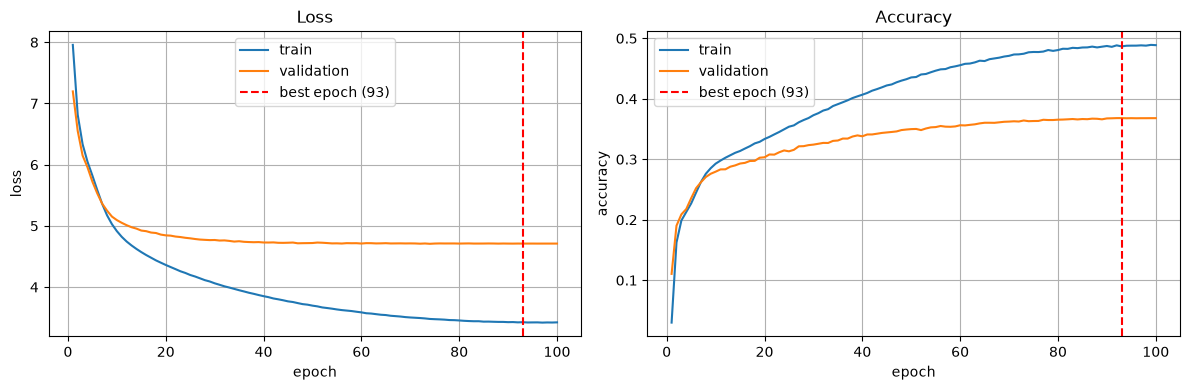

총 학습 에폭: 100
best epoch: 93 (val_acc 0.3681)


In [77]:
epochs = range(1, len(history['loss']) + 1)
best_epoch = history['best_epoch']

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history['loss'], label='train')
plt.plot(epochs, history['val_loss'], label='validation')
plt.axvline(best_epoch, color='r', linestyle='--', label='best epoch ({})'.format(best_epoch))
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, history['acc'], label='train')
plt.plot(epochs, history['val_acc'], label='validation')
plt.axvline(best_epoch, color='r', linestyle='--', label='best epoch ({})'.format(best_epoch))
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print('총 학습 에폭: {}'.format(len(history['loss'])))
print('best epoch: {} (val_acc {:.4f})'.format(best_epoch, history['best_val_acc']))

## Step 5. 모델 평가하기
---

In [78]:
def generate(model, sentence, tokenizer, device='cpu', max_length=None):
    """[변경] decoder_inference를 프롬프트 이어쓰기 방식으로 교체

    GPT의 학습 시퀀스는 Start + Question + Delim + Answer + Extract 하나이므로,
    추론에서는 Start + Question + Delim 까지를 프롬프트로 주고 그 뒤를 모델이 이어서 생성하게 한다.
    """
    START_TOKEN = tokenizer.bos_id()                  # Start
    END_TOKEN = tokenizer.eos_id()                    # Extract
    DELIM_TOKEN = tokenizer.piece_to_id('<delim>')    # [변경] Delim

    if max_length is None:
        max_length = MAX_LENGTH

    # 전처리 (학습 때와 동일하게)
    sentence = preprocess_sentence(sentence)
    q_ids = tokenizer.encode(sentence)

    # [변경] 프롬프트 = Start + Question + Delim
    prompt = ([START_TOKEN] + q_ids + [DELIM_TOKEN])[:max_length]
    generated = torch.tensor([prompt], dtype=torch.long, device=device)

    model.eval()
    with torch.no_grad():
        # 컨텍스트 길이를 넘지 않을 때까지 한 토큰씩 생성
        while generated.size(1) < max_length:
            logits = model(generated)             # (1, seq_len, vocab_size)

            # 마지막 위치의 예측만 사용
            last_step_logits = logits[:, -1, :]   # (1, vocab_size)

            # argmax로 가장 높은 확률의 토큰 선택
            predicted_id = torch.argmax(last_step_logits, dim=-1)  # (1,)

            # 종료 토큰(Extract)이면 중단
            if predicted_id.item() == END_TOKEN:
                break

            # 생성한 토큰을 시퀀스에 이어붙여 다음 스텝의 입력으로 사용
            generated = torch.cat([generated, predicted_id.unsqueeze(0)], dim=1)

    # [변경] 프롬프트 구간을 제외하고 생성된 답변 부분만 반환
    answer_ids = generated.squeeze(0).tolist()[len(prompt):]

    return answer_ids

In [79]:
def sentence_generation(model, sentence, tokenizer, device='cpu'):
    # [변경] decoder_inference -> generate, 반환값은 답변 구간의 토큰 id
    answer_ids = generate(model, sentence, tokenizer, device=device)

    predicted_sentence = tokenizer.decode(answer_ids)

    print("입력 :", sentence)
    print("출력 :", predicted_sentence)
    return predicted_sentence

In [80]:
sentence = '잘 지냈어?'
sentence_generation(model, sentence, sp, device)

입력 : 잘 지냈어?
출력 : 잘 지낼 거예요 .


'잘 지낼 거예요 .'

In [81]:
sentence = '배고프다.'
sentence_generation(model, sentence, sp, device)

입력 : 배고프다.
출력 : 얼른 얼른 얼른 뭐라도 드세요 .


'얼른 얼른 얼른 뭐라도 드세요 .'

In [82]:
sentence = '해외로 놀러가고 싶다~!'
sentence_generation(model, sentence, sp, device)

입력 : 해외로 놀러가고 싶다~!
출력 : 여행은 항상 좋아요 .


'여행은 항상 좋아요 .'

In [86]:
sentence = '감기에 걸렸어.'
sentence_generation(model, sentence, sp, device)

입력 : 감기에 걸렸어.
출력 : 병원가세요 .


'병원가세요 .'

In [95]:
sentence = '어깨가 너무 아프다.'
sentence_generation(model, sentence, sp, device)

입력 : 어깨가 너무 아프다.
출력 : <delim>꾹꾹꾹꾹꾹꾹꾹 !


'<delim>꾹꾹꾹꾹꾹꾹꾹 !'

---

## 회고

Transformer와 GPT는 인코더만 없고 디코더 부분은 비슷하니 수정이 쉬울 거라 생각했는데 디코더에 연결된 지점이 생각보다 많았다. 인코더를 지우자 Cross-Attention이 참조할 대상이 사라졌고, 그러자 마스크 두 개가 필요 없어졌다. 앞부분을 놓치면 뒷부분이 실행되지 않아 순서대로 짚어가는 데 시간이 오래 걸렸다. 구조를 바꾸는 일이 클래스 몇 개를 제거하는 것이 아니라, 그 클래스가 만들어내던 결과들을 전부 수정하며 맞추는 일이라는 것을 알게 되었다.

가장 오래 헤맨 곳은 임베딩 부분이다. Transformer를 구현하면서 sin/cos 위치 인코딩과 임베딩 크기를 맞추기 위해 스케일링을 추가했었다. 위치 인코딩을 학습 가능한 위치 임베딩으로 바꾸는 순간 스케일할 대상이 없어졌고 임베딩의 초기 스케일을 초기화가 직접 정해야 해서 논문의 N(0, 0.02)를 사용했다. 위치 인코딩 방식, 스케일링, 초기화, 가중치 공유가 독립된 항목이 아니라 서로를 전제하고 있어 수정에 시간이 오래 걸렸다.

논문에 맞춰 학습률도 수정했는데 이 설정이 이번 학습에는 맞지 않았다. 최대 학습률 2.5e-4에 cosine annealing을 적용했더니, 기존에 쓰던 Noam 스케줄이 학습을 끝낼 때의 학습률보다도 낮은 값으로 전 구간을 돌게 되었다. train acc는 0.4883, train loss는 3.42에서 평탄해졌고 마지막 10에폭동안 val_acc가 0.3671에서 0.3681 사이에 머물렀다. 더 학습될 여지가 남았는데 학습률이 먼저 0이 되버렸다. 논문의 2.5e-4는 12층 768차원 모델을 BooksCorpus로 학습할 때의 값이라 2층 256차원에 11,683쌍인 이번 조건에는 부적절했다. 구조는 논문을 따르더라도 학습 설정은 조건에 맞춰 다시 정했어야 했다.

생성 결과는 5개 중 4개가 맥락에 맞았다. Exploration에서 `칭찬 감사합니다.`로 빗나갔던 `해외로 놀러가고 싶다~!`에 `여행은 항상 좋아요.`로 답했다. 대신 `얼른 얼른 얼른 뭐라도 드세요.`, `저도 저도 해보고 싶어요.`처럼 같은 토큰을 반복하는 문제가 새로 나타났다.